# SILVA Psi-GNN for Mixed-Boundary Poisson Problems

This lab derives the boundary-aware graph, typed message maps, fixed-point
processor, residual objective, and source-scale route of Psi-GNN [[60]](https://jseluis.github.io/silva-networks/paper/references/#ref-60). It uses
a known mixed-boundary field, then trains a compact SILVA model while retaining
the equation and boundary diagnostics.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[60]](https://jseluis.github.io/silva-networks/paper/references/#ref-60), [[72]](https://jseluis.github.io/silva-networks/paper/references/#ref-72). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from silva_networks import (
    SILVAPsiGNN,
    SILVAPsiGNNProcessor,
    SolverConfig,
    make_psi_poisson_grid,
)

## 1. PDE, Discretization, and Directed Boundary Graph

$$
-\Delta u=f\ \text{in }\Omega,
\quad u=g\ \text{on }\partial\Omega_D,
\quad \partial_nu=0\ \text{on }\partial\Omega_N.
$$

First-order discretization gives $AU=B$ and
$\mathcal L_{res}=N^{-1}\lVert AU-B\rVert_2^2$. Replacing Dirichlet rows by
identity rows makes Dirichlet nodes send known values without receiving graph
updates. Interior and Neumann stencils remain bidirectional.

In [3]:
data = make_psi_poisson_grid(size=11)
equation_error = (data.stiffness @ data.target - data.rhs).abs().max()
assert equation_error < 1e-6
print("nodes/edges:", data.coordinates.shape[0], data.edge_index.shape[1])
print("interior/Dirichlet/Neumann:", torch.bincount(data.node_types).tolist())
print("exact discrete residual:", float(equation_error))

nodes/edges: 121 378
interior/Dirichlet/Neumann: [81, 22, 18]
exact discrete residual: 0.0


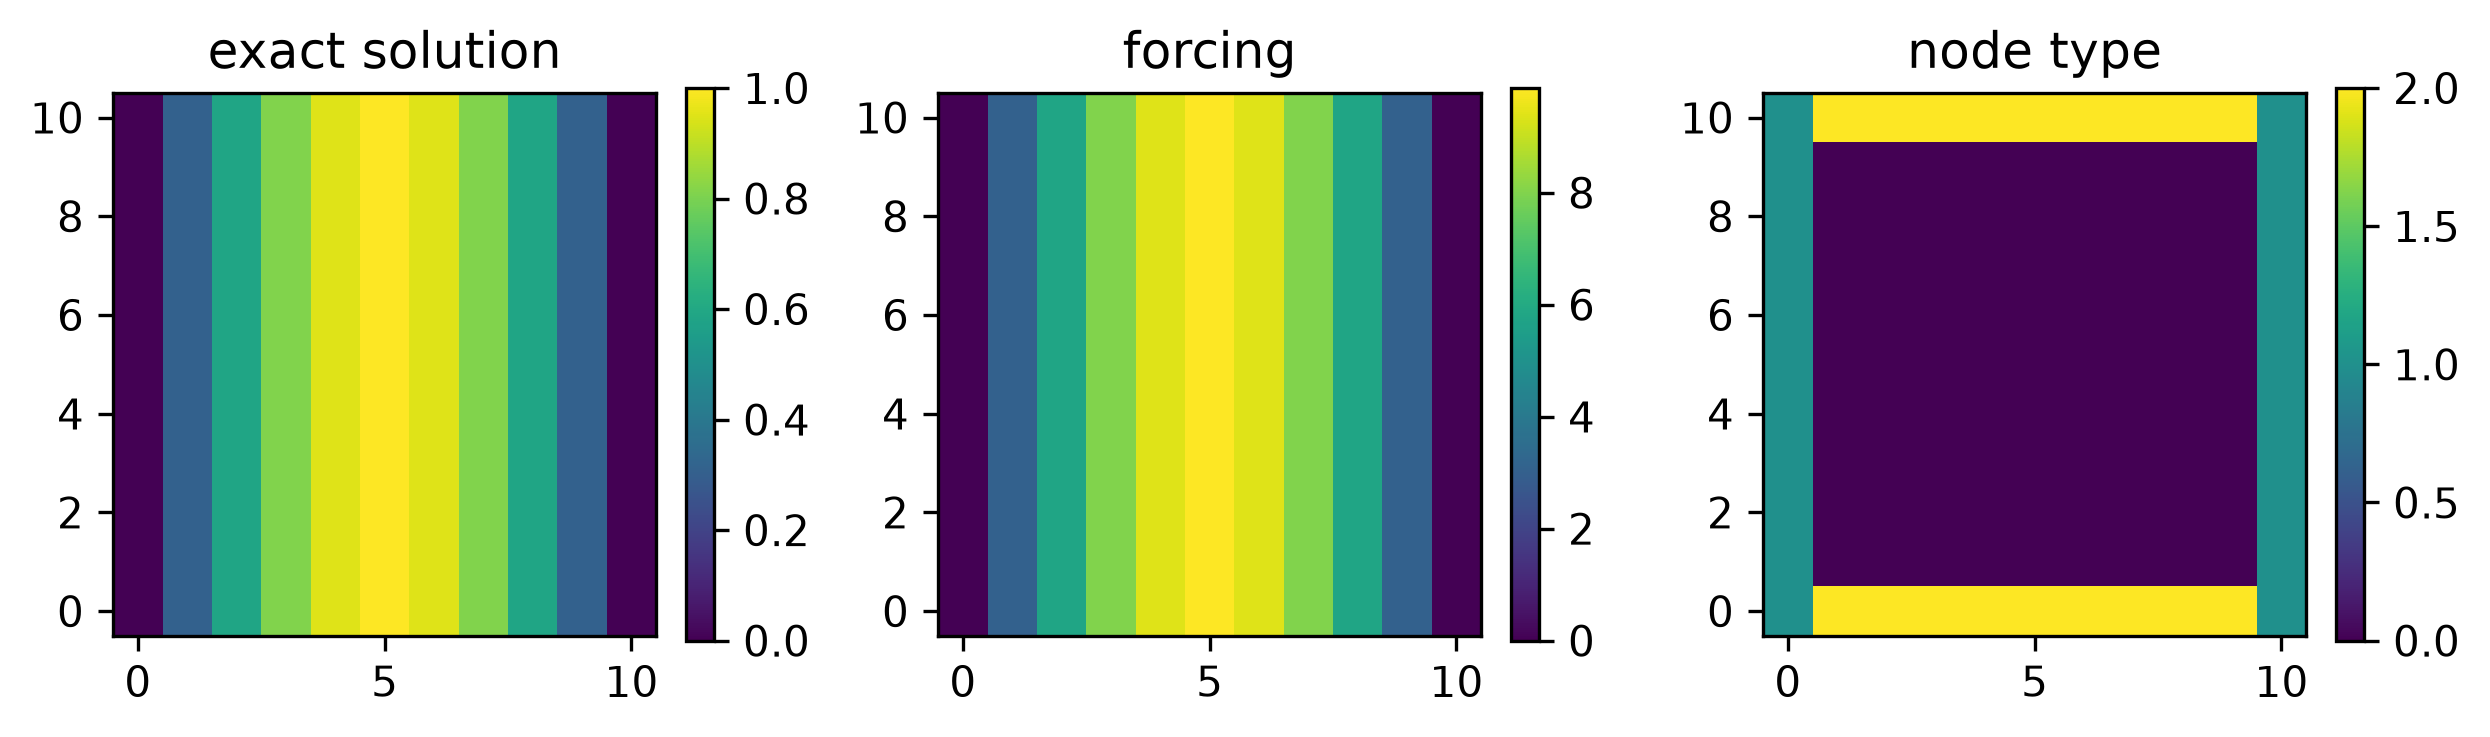

In [4]:
size = int(data.coordinates.shape[0] ** 0.5)
figure, axes = plt.subplots(1, 3, figsize=(8.4, 2.6))
for axis, values, title in zip(
    axes,
    [data.target, data.forcing, data.node_types[:, None].float()],
    ["exact solution", "forcing", "node type"],
):
    image = axis.imshow(values.reshape(size, size), origin="lower", cmap="viridis")
    axis.set_title(title)
    figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

## 2. Typed Processor

Interior nodes receive separate incoming and outgoing messages,

$$\phi^I_{\leftarrow,i}=\sum_j\Phi^I_{\leftarrow}(H_i,H_j,d_{ji},\|d_{ji}\|),$$

$$\phi^I_{\rightarrow,i}=\sum_j\Phi^I_{\rightarrow}(H_i,H_j,d_{ij},\|d_{ij}\|),$$

and a residual update $z_i^I=H_i+\Lambda^I(H_i,b_i,\phi^I_\leftarrow,
\phi^I_\rightarrow)$. Neumann updates use their own message map and outward
normal. Dirichlet latent values stay equal to the encoded initial condition.

In [5]:
processor = SILVAPsiGNNProcessor(12, update_scale=0.12, normalize=False)
model = SILVAPsiGNN(
    12,
    processor=processor,
    config=SolverConfig(
        solver="picard", max_iter=12, tol=1e-5, backward_mode="unrolled"
    ),
)

def solve():
    return model(
        data.initial_solution,
        data.forcing,
        data.coordinates,
        data.edge_index,
        data.node_types,
        boundary_values=data.boundary_values,
        normals=data.normals,
        return_result=True,
    )

initial = solve()
assert initial.boundary_error == 0
print("output/state shapes:", initial.output.shape, initial.state.shape)
print("boundary error:", float(initial.boundary_error))
print("root residual:", initial.solver_result.residual)

output/state shapes: torch.Size([121, 1]) torch.Size([121, 12])
boundary error: 0.0
root residual: 0.7236002683639526


## 3. Complete Training Objective

The full construction combines equation residual, optional light supervision,
Jacobian stabilization, latent consistency, and encoder-decoder reconstruction.
The compact run emphasizes the known solution so progress is visible quickly;
the source experiment emphasizes the finite-element residual.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for _ in range(35):
    optimizer.zero_grad()
    result = solve()
    terms = model.loss(
        result,
        data.stiffness,
        data.rhs,
        exact=data.target,
        supervised_weight=1.0,
    )
    terms.total.backward()
    optimizer.step()
    losses.append(float(terms.total.detach()))

trained = solve()
field_error = torch.mean((trained.output - data.target).square()).sqrt()
print("initial/final objective:", losses[0], losses[-1])
print("field RMSE:", float(field_error))
print("boundary error:", float(trained.boundary_error))

initial/final objective: 253.99069213867188 20.918502807617188
field RMSE: 0.4059576988220215
boundary error: 0.0


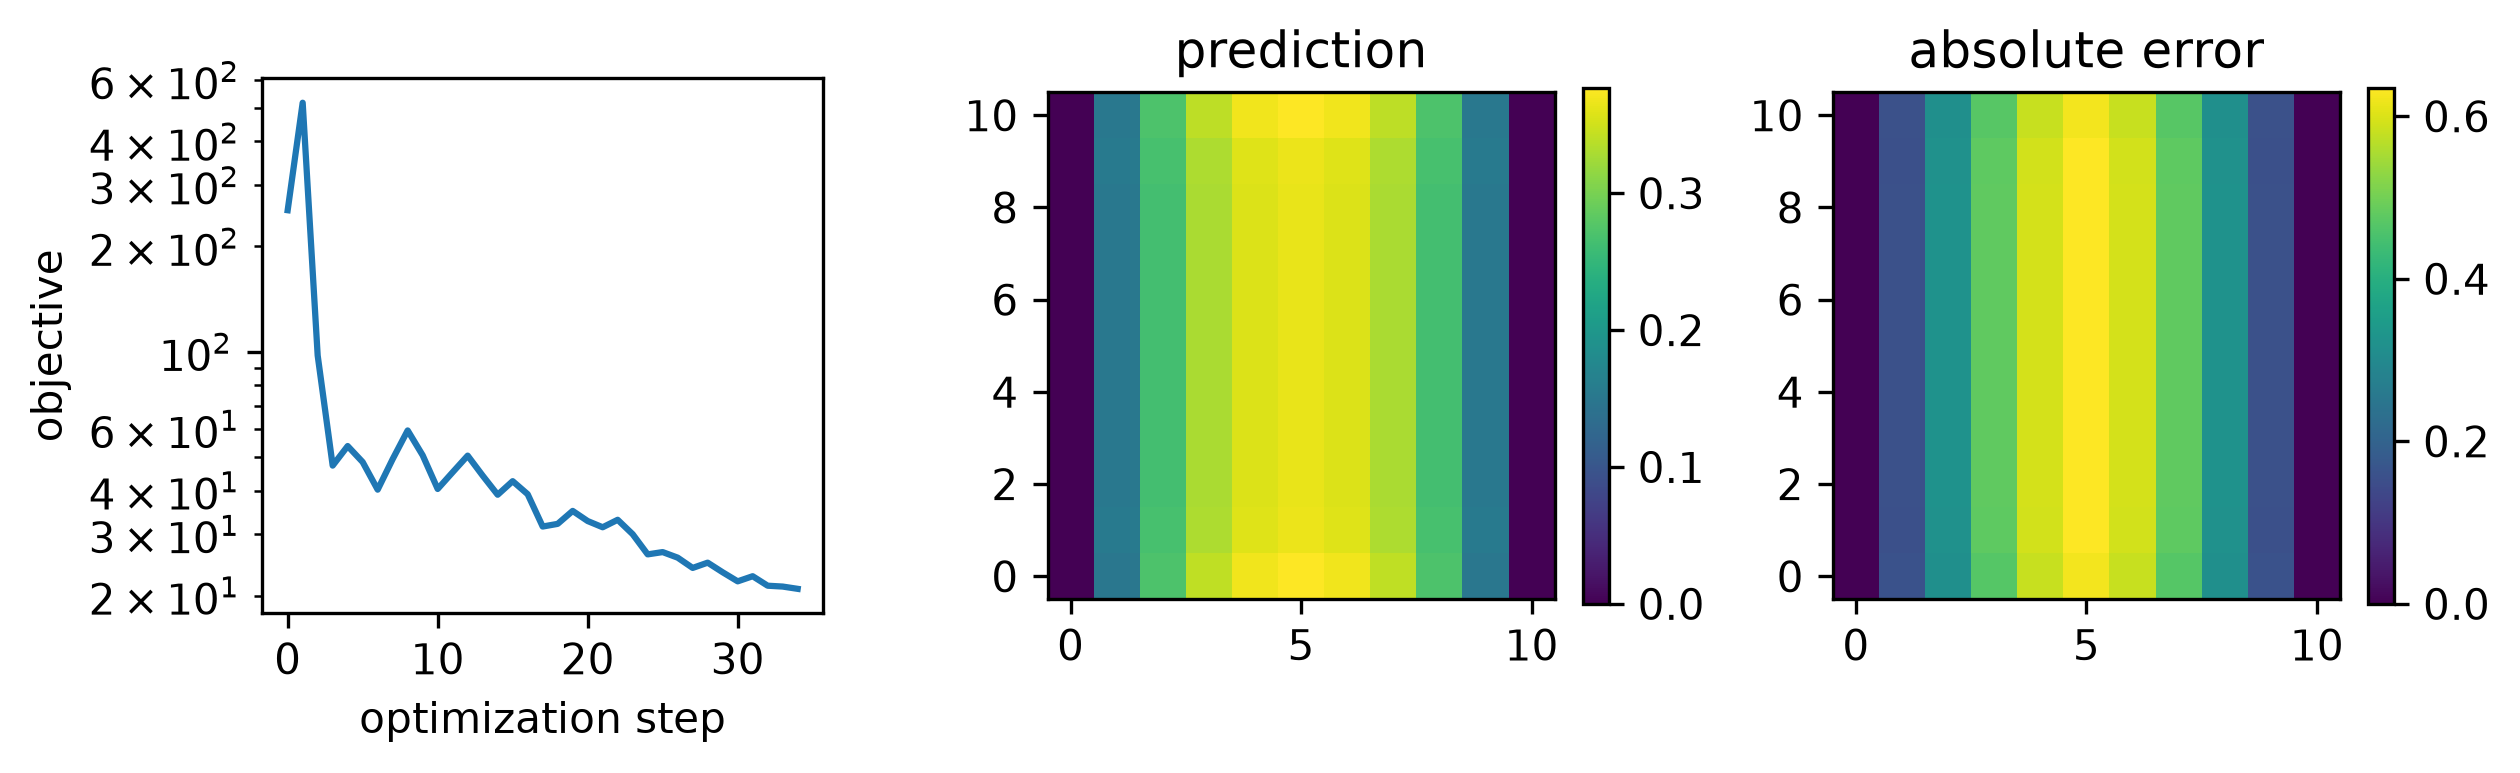

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(8.5, 2.6))
axes[0].semilogy(losses)
axes[0].set(xlabel="optimization step", ylabel="objective")
predicted = trained.output.detach().reshape(size, size)
error = (predicted - data.target.reshape(size, size)).abs()
images = [predicted, error]
for axis, values, title in zip(axes[1:], images, ["prediction", "absolute error"]):
    image = axis.imshow(values, origin="lower", cmap="viridis")
    axis.set_title(title)
    figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

## 4. From This Grid to the Source Experiment

Regenerate first-order unstructured meshes, mark Dirichlet/interior/Neumann
nodes, derive directed edges from the boundary-modified stencil, and retain
coordinates, distances, normals, forcing, and boundary features. Use the FEM
matrices only for $AU-B$ during training and evaluation. Match the source
6000/2000/2000 split, approximately 500-node training meshes, optimizer groups,
Jacobian penalty, variable-resolution tests, residual, and MSE against the LU
solution. The same processor accepts each graph size without padding.

## Source Data and Full Experiment Preflight

The benchmark is generated from the paper protocol [[60]](https://jseluis.github.io/silva-networks/paper/references/#ref-60). Begin with 32-128 first-order Gmsh meshes [[72]](https://jseluis.github.io/silva-networks/paper/references/#ref-72), retain sparse finite-element objects, and restore the 6,000/2,000/2,000 split only after the equation and boundary diagnostics pass.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [8]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_psi_gnn')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://arxiv.org/abs/2302.10891
 - https://gmsh.info/
access:
 - The benchmark is procedurally generated rather than a fixed public archive.
 - Recreate first-order unstructured meshes and mixed boundaries from the paper protocol with Gmsh, then save generator parameters and mesh checksums.
storage:
 - Plan separately for node features, directed edge indices/features, targets, and optional sparse finite-element matrices.
 - Measure one serialized mesh after preprocessing and multiply by 10,000; shard by graph count so matrices are never densified.
source-scale steps:
 1. Generate the 6000/2000/2000 mesh split with first-order elements, mixed boundaries, and approximately 500 training nodes per graph.
 2. Convert each mesh to the SILVAPsiGNN tensor contract without densifying edges or finite-element matrices.
 3. Train residual, Jacobian, latent-consistency, and reconstruction terms, then evaluate new geometries, resolutions, boundaries, and initial states.


## From 29 Silva Psi Gnn to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one latent vector per node or entity |
| Condition | node features, edges, edge attributes, and graph batches |
| Repeated computation | a source-injected graph message or monotone graph transition |
| Required invariants | node relabeling equivariance, graph boundaries, and state shape |
| Replaceable components | input projection, message field, global field, transition, pooling, and head |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Boundary-Aware Graph Processor

```python
model = SILVAPsiGNN(
    in_dim=input_dim,
    state_dim=width,
    out_dim=1,
    processor=my_boundary_aware_processor,
    encoder=my_node_encoder,
    decoder=my_solution_decoder,
    config=solver_config,
)
```

The processor receives the current node state, directed edges, node types, and
boundary normals. A source-scale reproduction must construct the mixed
Dirichlet/Neumann graph exactly, hold prescribed Dirichlet states fixed, and
report algebraic residual, boundary error, solution error, and solver residual
separately.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**node/graph error, physical graph residual, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **node count, edge count, feature width, and number of graphs**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '29_silva_psi_gnn.ipynb',
    "state": 'one latent vector per node or entity',
    "condition": 'node features, edges, edge attributes, and graph batches',
    "transition": 'a source-injected graph message or monotone graph transition',
    "invariants": 'node relabeling equivariance, graph boundaries, and state shape',
    "compact_metric": 'node/graph error, physical graph residual, and fixed-point residual',
    "scale_axis": 'node count, edge count, feature width, and number of graphs',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '29_silva_psi_gnn.ipynb',
 'state': 'one latent vector per node or entity',
 'condition': 'node features, edges, edge attributes, and graph batches',
 'transition': 'a source-injected graph message or monotone graph transition',
 'invariants': 'node relabeling equivariance, graph boundaries, and state shape',
 'compact_metric': 'node/graph error, physical graph residual, and fixed-point residual',
 'scale_axis': 'node count, edge count, feature width, and number of graphs'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **one latent vector per node or entity**, and its repeated map,
**a source-injected graph message or monotone graph transition**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


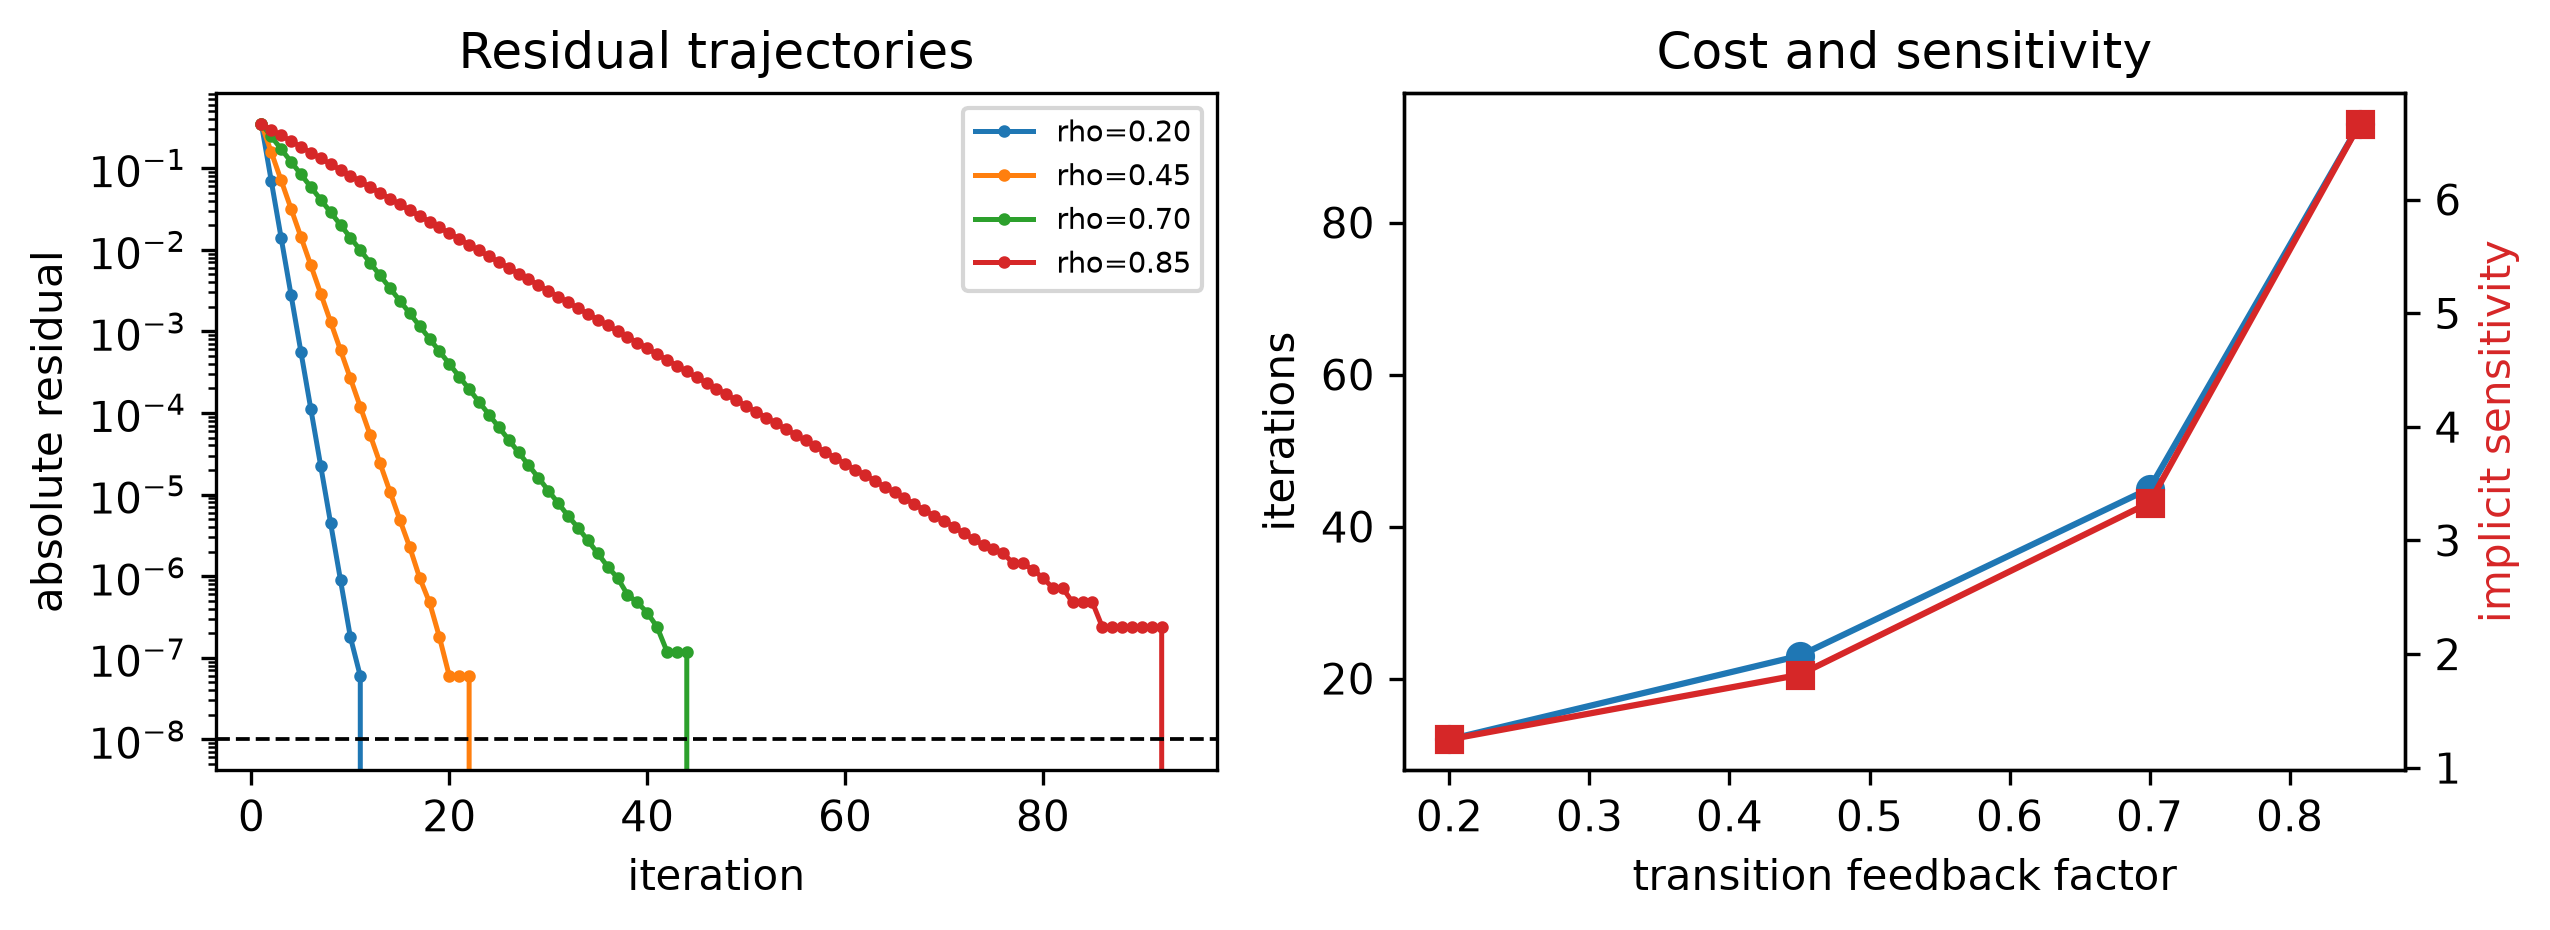

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | node/graph error, physical graph residual, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | node relabeling equivariance, graph boundaries, and state shape |
| Scale sweep | Change one of node count, edge count, feature width, and number of graphs at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How are mixed boundaries represented in the graph equilibrium? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#psi-gnn) |
| Which graph model and compact Poisson data are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| How do graph PDEs connect to the wider SILVA structure? | [Neural Operators, ODEs, PDEs, and SILVA](https://jseluis.github.io/silva-networks/learn/neural-operators-ode-pde/) |
